# Ocean colour Climatology and Bathymetry
## Core 3 CS- Saldanha Bay Coastal Region
This notebook forms a part of the SAMS Core 3 Capstone Group assignment.
The objective is to visualise and analyse climatological satellite-derived
chlorophyll concentrations together with bathymetric information for a
coastal region of interest.
**Region:** Saldanha Bay and adjacent West Coast of South Africa





In [1]:
# Import core scientific Python libraries
import xarray as xr               # For working with NetCDF data
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Plotting
import cartopy.crs as ccrs        # Map projections
import cartopy.feature as cfeature
import cmocean                    # Oceanographically appropriate colormaps

## Bathymetry (GMRT)

Bathymetry describes the depth and shape of the seafloor and provides
important physical context for interpreting chlorophyll distributions.
In this section, bathymetric data from the Global Multi-Resolution
Topography (GMRT) dataset are loaded, inspected, and visualised for the
Saldanha Bay region.

In [2]:

# Define data directory relative to repository
DATA_DIR = "Capstone_Assesment/"

# Define dataset paths
bathy_path = DATA_DIR + "GMRTv4_4_1_20260512topo.grd"
chl_path = DATA_DIR + "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc"

# Check if files exist 
import os

if not os.path.exists(bathy_path):
    raise FileNotFoundError(
        f"Bathymetry file not found at {bathy_path}. "
        "Place it inside the Capstone_Assesment folder."
    )

if not os.path.exists(chl_path):
    raise FileNotFoundError(
        f"Chlorophyll file not found at {chl_path}. "
        "Place it inside the Capstone_Assesment folder."
    )

In [3]:
# Load GMRT bathymetry data from a GMT grid (.grd) file.
# Although the file extension is .grd, it follows NetCDF conventions
# and can be read directly using xarray.

bathy = xr.open_dataset(bathy_path)

bathy


<xarray.Dataset> Size: 237MB
Dimensions:    (side: 2, xysize: 29660832)
Dimensions without coordinates: side, xysize
Data variables:
    x_range    (side) float64 16B ...
    y_range    (side) float64 16B ...
    z_range    (side) float64 16B ...
    spacing    (side) float64 16B ...
    dimension  (side) int32 8B ...
    z          (xysize) float64 237MB ...
Attributes:
    title:    GMRT Grid
    source:   \n\tProjection: Cylindrical Equidistant\n\tCreated with GMRT Ma...

### Bathymetry Dataset Description

The bathymetry data were obtained from the Global Multi-Resolution
Topography (GMRT) synthesis using the GMRT MapTool.

The dataset is provided as a GMT grid (`.grd`) file. Although this
differs from the standard `.nc` extension, the file follows NetCDF
conventions and is fully compatible with xarray.

The primary variable represents seafloor elevation, where negative
values indicate ocean depth.

In [4]:
# Identify the available data variables in the bathymetry dataset

list(bathy.data_vars)


['x_range', 'y_range', 'z_range', 'spacing', 'dimension', 'z']

In [5]:
# Extract grid dimensions (number of points in x and y)
nx, ny = bathy.dimension.values
nx, ny


(np.int32(4552), np.int32(6516))

In [6]:
# Reshape the bathymetry data into a 2D grid
z = bathy.z.values.reshape((ny, nx))

z.shape


(6516, 4552)

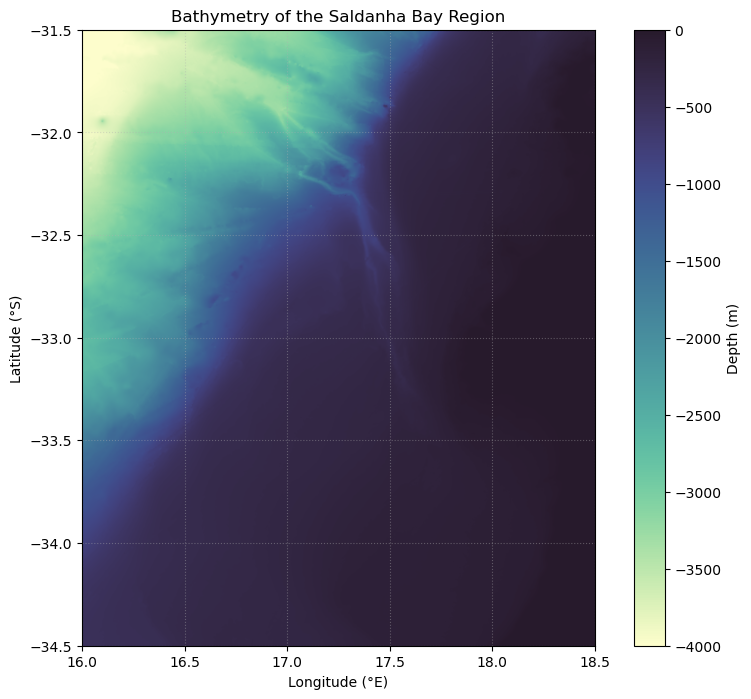

In [7]:

# Extract coordinate limits
x_min, x_max = bathy.x_range.values
y_min, y_max = bathy.y_range.values

# Plot bathymetry of the Saldanha Bay region

plt.figure(figsize=(10, 8))

plt.imshow(
    z,
    origin="lower",
    cmap=cmocean.cm.deep,
    vmin=-4000,
    vmax=0,
    extent=[x_min, x_max, y_min, y_max]
)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label("Depth (m)")

# Labels and title
plt.title("Bathymetry of the Saldanha Bay Region")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°S)")

# Improve readability
plt.grid(True, linestyle=":", alpha=0.4)

# Save figure
plt.savefig("figures/bathymetry_saldanha.png", dpi=300, bbox_inches="tight")

plt.show()



# A faceted figure, showing 12 maps, one for each month showing spatial distribution of chlorophyll-a concentration across the study region



In [44]:
# 1. Open your dataset
ds = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY.nc")

In [45]:
#Extracts the chlorophyll variable from the dataset
chl = ds['chlor_a']   


In [46]:
#check coordinates range
print(ds['lat'].values.min(), ds['lat'].values.max())
print(ds['lon'].values.min(), ds['lon'].values.max())

-89.97916666666666 89.97916666666667
-179.97916666666666 179.97916666666663


In [47]:
#Subset the chlorophyll dataset to the study area Saldanha Bay to reduce 
#the dataset to the spatial extent 16°E–18.5°E, 34.5°S–31.5°S
# to ensure consistency with the bathymetry data 

subset = chl.sel(lon=slice(16.0, 18.5), lat=slice(-31.5, -34.5))


In [31]:
print(subset)


<xarray.DataArray 'chlor_a' (time: 12, lat: 72, lon: 60)> Size: 207kB
[51840 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 576B -31.52 -31.56 -31.6 ... -34.4 -34.44 -34.48
  * lon      (lon) float64 480B 16.02 16.06 16.1 16.15 ... 18.4 18.44 18.48
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


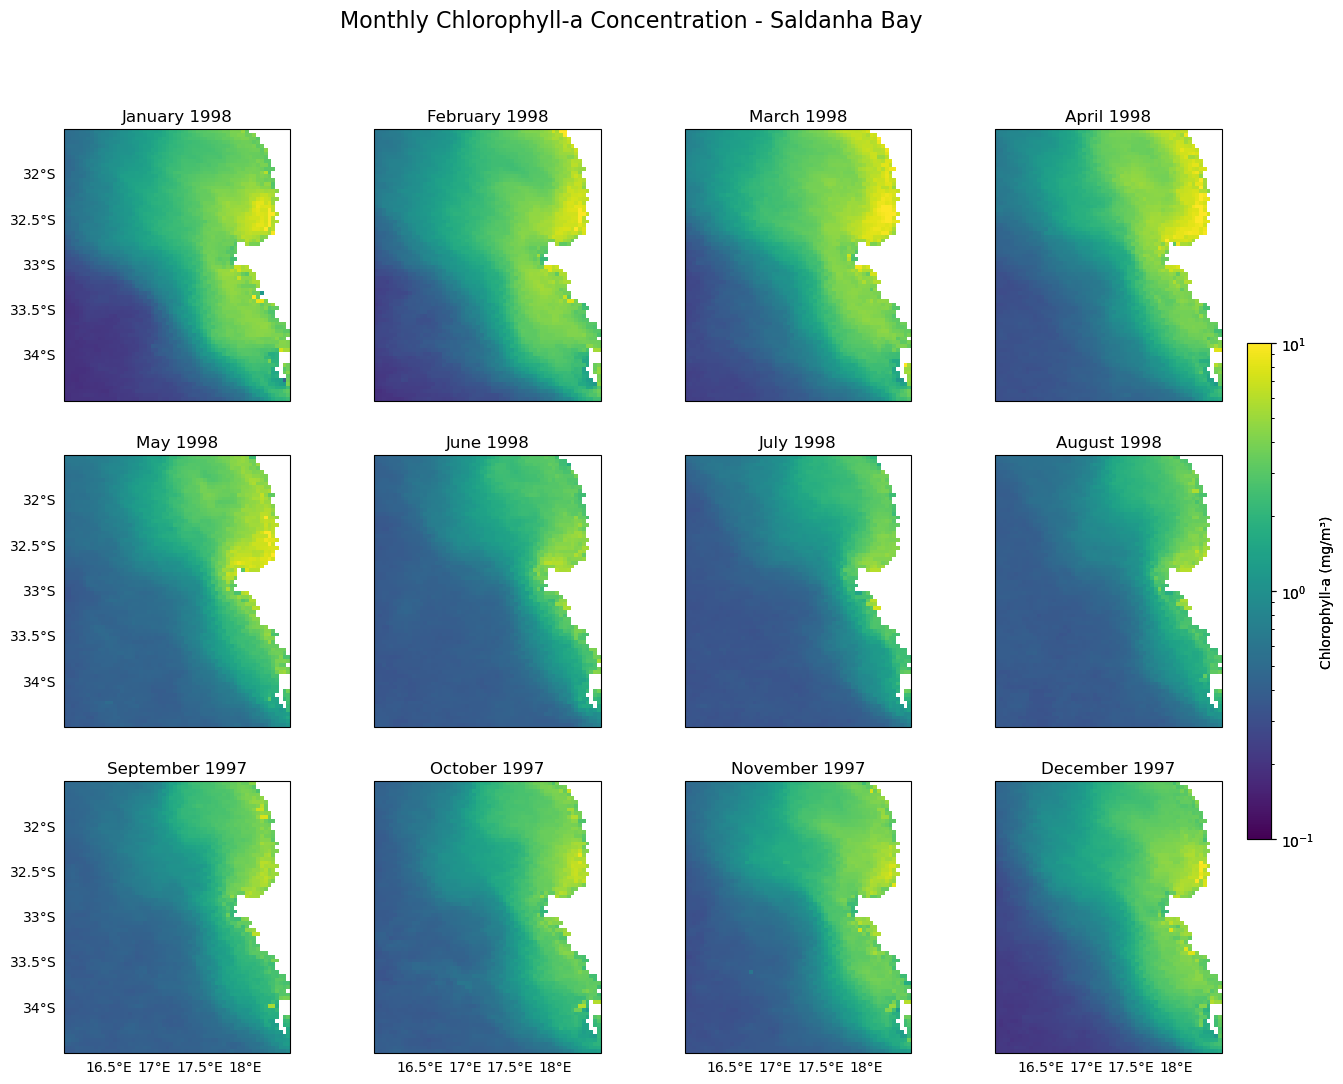

In [48]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
import pandas as pd

# Open dataset ESACCI-OC-MAPPED-CIMATOLOGY.nc
ds = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY.nc")

# Faceted plot
fig, axes = plt.subplots(
    nrows=3, ncols=4, figsize=(16, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# Keep a reference to the first plot so we can add a shared colorbar later
im = None

for i, ax in enumerate(axes):
    da = subset.isel(time=i)
    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        norm=LogNorm(vmin=0.1, vmax=10),
        add_colorbar=False   
    )

    # Labels only on outer edges
    gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 4 == 0)      # left column only
    gl.bottom_labels = (i >= 8)        # bottom row only

    # Month title
    date = pd.to_datetime(da['time'].values)
    ax.set_title(date.strftime("%B %Y"))

# Shared vertical colorbar on the right side
cbar = fig.colorbar(
    im, ax=axes, orientation='vertical',
    fraction=0.02, pad=0.02
)
cbar.set_label("Chlorophyll-a (mg/m³)")

plt.suptitle("Monthly Chlorophyll-a Concentration - Saldanha Bay", fontsize=16)
plt.subplots_adjust(right=0.9) 
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("Chlorophyll-a (mg/m³)")
plt.show()


# A timeseries plot showing two lines: the mean seasonal cycle of the whole region compared with the time series from a single grid point of high chlorophyll


In [51]:
regional_mean = subset.mean(dim=['lat','lon'])

In [52]:
point_ts = subset.sel(lon=17.0, lat=-33.0, method='nearest')


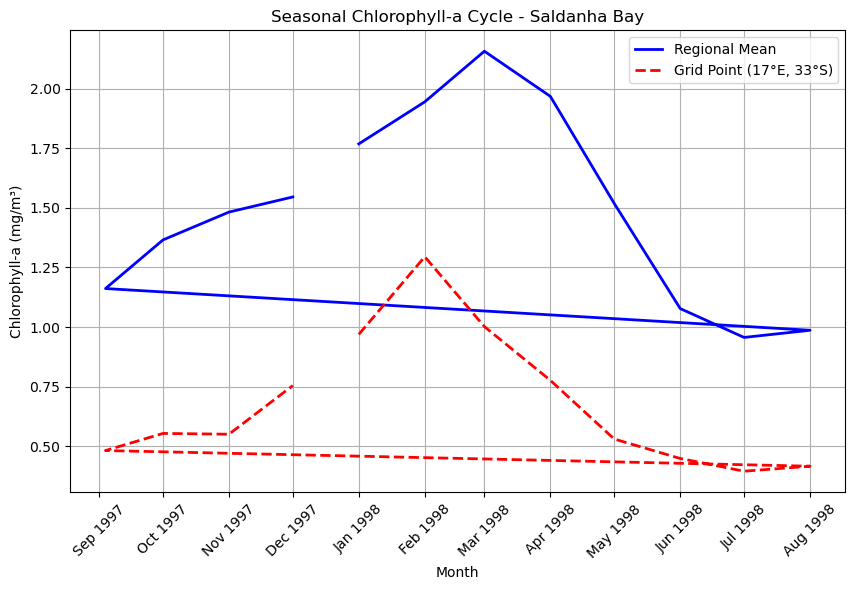

In [65]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


plt.figure(figsize=(10,6))

# Regional mean
plt.plot(regional_mean['time'], regional_mean,
         label='Regional Mean', linewidth=2, color='blue')

# making the grid point line dashed to distinguish it from the regional mean
plt.plot(point_ts['time'], point_ts,
         label='Grid Point (17°E, 33°S)',
         linewidth=2,
         color='red',
         linestyle='--') 

plt.title("Seasonal Chlorophyll-a Cycle - Saldanha Bay")
plt.xlabel("Month")
plt.ylabel("Chlorophyll-a (mg/m³)")
plt.legend()
plt.grid(True)

# Format x-axis to show month names
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())          
# rotate x-axis labels to avoid overlap
plt.xticks(rotation=45)
plt.show()
